In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("gym_crowdedness.csv")

In [3]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [4]:
df.shape

(62184, 11)

In [5]:
df.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [6]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [8]:
df['date'] = pd.to_datetime(df['date'], utc = True)

In [9]:
def fahrenheit_to_celsius(fahrenheit):
    return (fahrenheit - 32) * 5 / 9

df['temperature'] = df['temperature'].apply(fahrenheit_to_celsius)
# df['temperature'] = df['temperature'].apply(lambda f: (f - 32) * 5 / 9)

In [10]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,22.088889,0,0,8,17
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,22.088889,0,0,8,17
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,22.088889,0,0,8,17
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,22.088889,0,0,8,17
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,22.088889,0,0,8,17


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [12]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,22.088889,0,0,8,17
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,22.088889,0,0,8,17
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,22.088889,0,0,8,17
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,22.088889,0,0,8,17
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,22.088889,0,0,8,17


In [13]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,14.753949,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,3.509109,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,3.411111,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,12.777778,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,14.633333,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,16.822222,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,30.650000,1.000000,1.000000,12.000000,23.000000


In [14]:
df['date'].dt.year # you can get  year/month/day by this way
# df['date'].dt.month
# df['date'].dt.day
# df['date'].dt.hour

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
62179    2017
62180    2017
62181    2017
62182    2017
62183    2017
Name: date, Length: 62184, dtype: int32

In [15]:
df['year'] = df['date'].dt.year

In [16]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,22.088889,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,22.088889,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,22.088889,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,22.088889,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,22.088889,0,0,8,17,2015


In [17]:
df['year'].unique()

array([2015, 2016, 2017])

In [18]:
df.drop('date', axis=1, inplace=True) # we have year, month, day, hour information so we can drop the date column

In [38]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,22.088889,0,0,8,17,2015
1,45,62414,4,0,0,22.088889,0,0,8,17,2015
2,40,63015,4,0,0,22.088889,0,0,8,17,2015
3,44,63616,4,0,0,22.088889,0,0,8,17,2015
4,45,64217,4,0,0,22.088889,0,0,8,17,2015


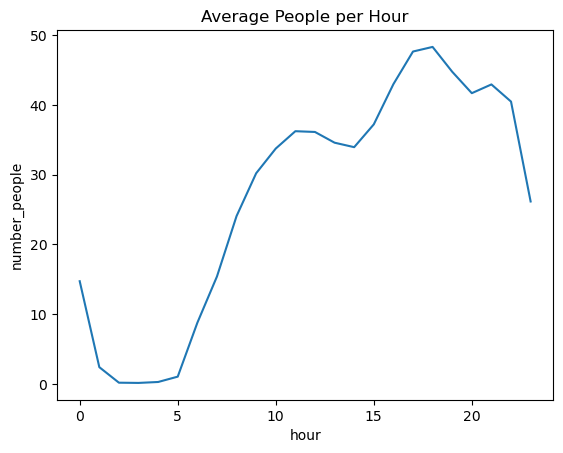

In [48]:
sns.lineplot(data=df, x="hour", y="number_people", errorbar=None)
plt.title("Average People per Hour")
plt.show()

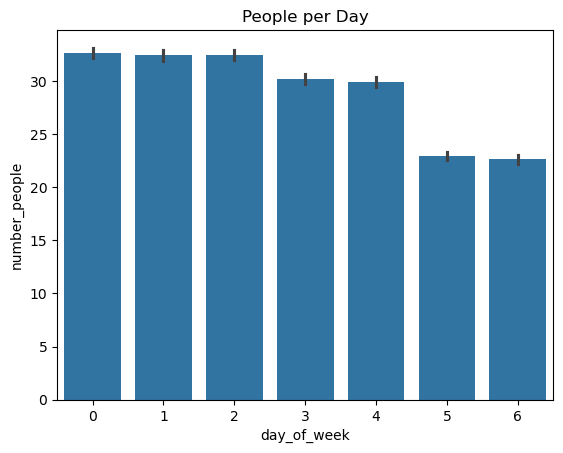

In [46]:
sns.barplot(data=df, x="day_of_week", y="number_people")
plt.title("People per Day")
plt.show()

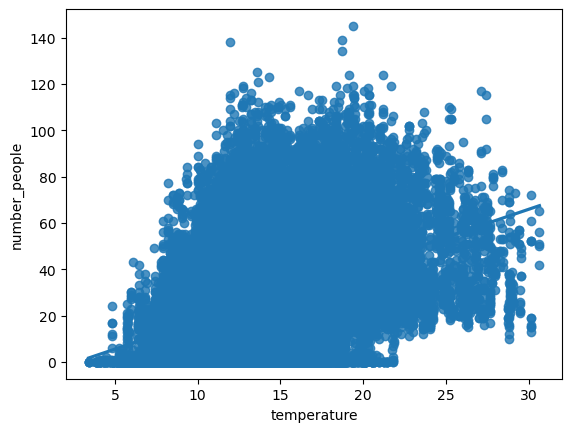

In [54]:
sns.regplot(data=df, x="temperature", y="number_people")
plt.show()

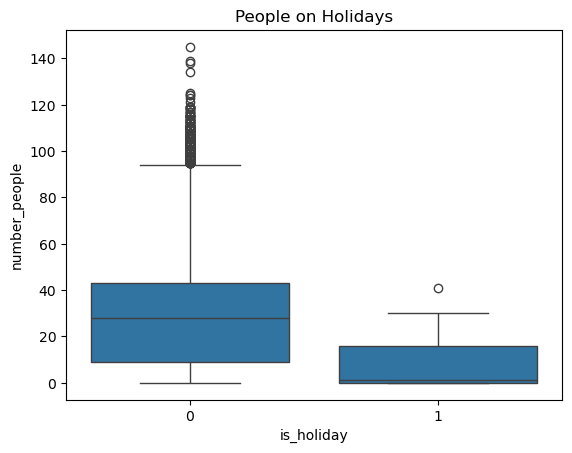

In [56]:
sns.boxplot(data=df, x="is_holiday", y="number_people")
plt.title("People on Holidays")
plt.show()

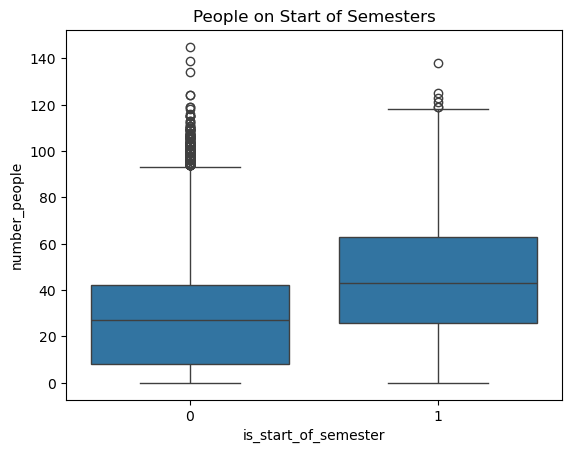

In [58]:
sns.boxplot(data=df, x="is_start_of_semester", y="number_people")
plt.title("People on Start of Semesters")
plt.show()

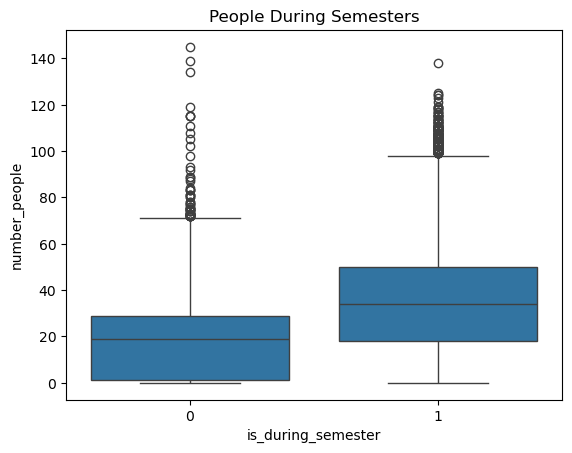

In [76]:
sns.boxplot(data=df, x="is_during_semester", y="number_people")
plt.title("People During Semesters")
plt.show()

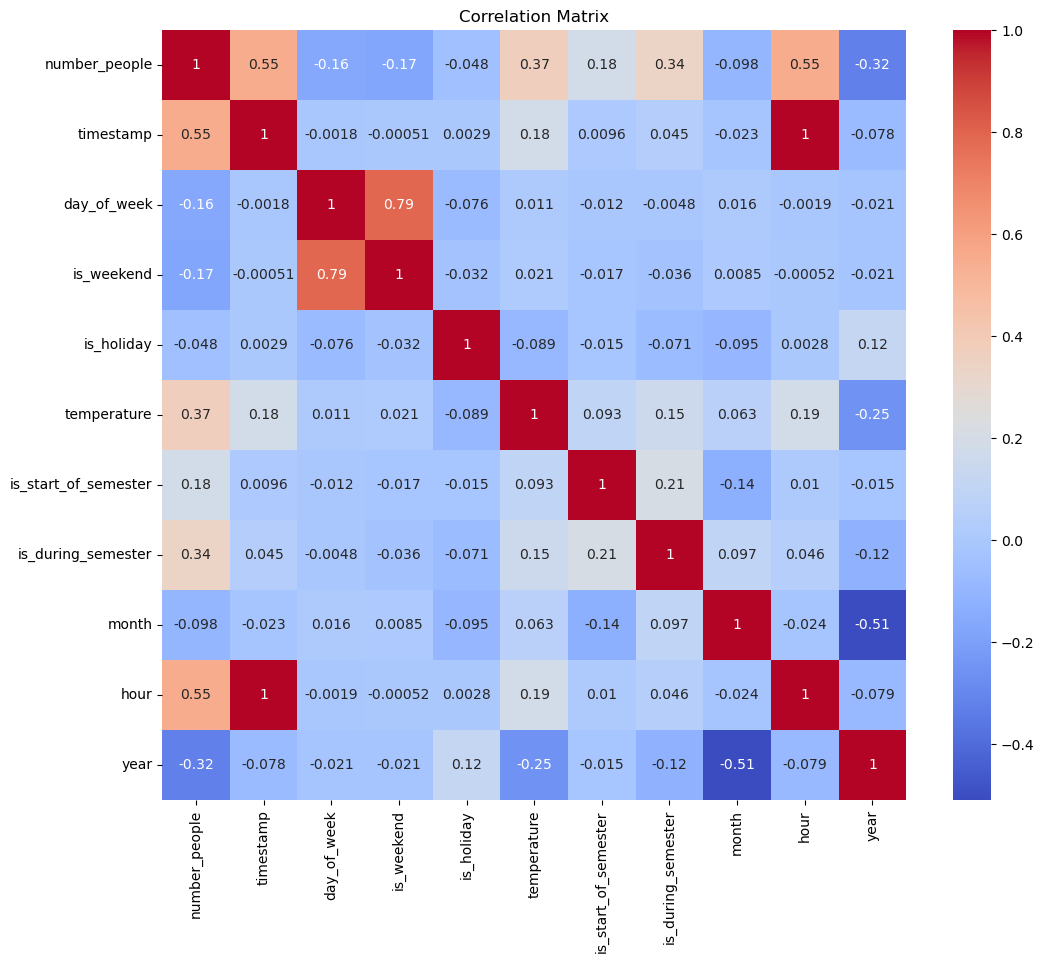

In [84]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [88]:
df = df.drop('timestamp',axis=1)

In [90]:
X = df.drop('number_people', axis=1)
y = df['number_people']

In [92]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [96]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [106]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [108]:
def calculate_model_metric(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    score = r2_score(true, predicted)
    return mae, rmse, score

In [110]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge": Ridge(),
    "K-Neighbours Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor()
}

In [ ]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metric(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metric(y_test,y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("RMSE :", model_train_rmse)
    print("Mean Absolute Error :", model_train_mae)
    print("R2 Score :", model_train_r2)

    print("-----------------------------")
    
    print("Evaluation for Test Set")
    print("RMSE :", model_test_rmse)
    print("Mean Absolute Error :", model_test_mae)
    print("R2 Score :", model_test_r2)

    print("-----------------------------")
    print("\n")

LinearRegression()
Evaluation for Training Set
RMSE : 14.322500408269727
Mean Absolute Error : 10.733469936454322
R2 Score : 0.5999639521710998
-----------------------------
Evaluation for Test Set
RMSE : 14.45063290337055
Mean Absolute Error : 10.779752371029556
R2 Score : 0.5989271376662775
-----------------------------


Lasso()
Evaluation for Training Set
RMSE : 14.569122351126817
Mean Absolute Error : 10.94518987422199
R2 Score : 0.5860687429058037
-----------------------------
Evaluation for Test Set
RMSE : 14.703511215751082
Mean Absolute Error : 10.97059490247691
R2 Score : 0.5847671974050243
-----------------------------


Ridge()
Evaluation for Training Set
RMSE : 14.322500413912243
Mean Absolute Error : 10.7334791788207
R2 Score : 0.5999639518559021
-----------------------------
Evaluation for Test Set
RMSE : 14.450633329986024
Mean Absolute Error : 10.77975955902301
R2 Score : 0.5989271139851151
-----------------------------


KNeighborsRegressor()
Evaluation for Training S

In [122]:
#hyperparameter tuning

In [148]:
knn_params = {
    'n_neighbors' : [2,3,10,20,40,50]
}
rfr_params = {
    'n_estimators' : [100, 200, 500, 1000],
    'max_depth' : [5, 8, 10,15, None],
    'max_features' : ['sqrt','log2', 5, 7, 10],
    'min_samples_split' : [2, 8, 12, 20]
}

In [150]:
from sklearn.model_selection import RandomizedSearchCV

In [152]:
randomcv_models = [
    ('KNN',KNeighborsRegressor(),knn_params),
    ('RFC',RandomForestRegressor(),rfr_params)
]

In [154]:
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params, n_jobs=-1, cv=3, scoring='r2', n_iter=100, verbose=3)
    randomcv.fit(X_train,y_train)
    print("Best Params for ",name,randomcv.best_params_)

C:\Users\ahmet\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Params for  KNN {'n_neighbors': 2}
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Params for  RFC {'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 5, 'max_depth': None}


In [157]:
# Best Params for  KNN {'n_neighbors': 2}
# Best Params for  RFC {'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 5, 'max_depth': None}

In [ ]:
models = {
    "K-Neighbours Regressor" : KNeighborsRegressor(n_neighbors= 2),
    "Random Forest Regressor" : RandomForestRegressor(n_estimators= 1000, min_samples_split= 2, max_features= 5, max_depth= None)
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metric(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metric(y_test,y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("RMSE :", model_train_rmse)
    print("Mean Absolute Error :", model_train_mae)
    print("R2 Score :", model_train_r2)

    print("-----------------------------")
    
    print("Evaluation for Test Set")
    print("RMSE :", model_test_rmse)
    print("Mean Absolute Error :", model_test_mae)
    print("R2 Score :", model_test_r2)

    print("-----------------------------")
    print("\n")

KNeighborsRegressor(n_neighbors=2)
Evaluation for Training Set
RMSE : 5.459929507262949
Mean Absolute Error : 3.5543762597023885
R2 Score : 0.9418652897023468
-----------------------------
Evaluation for Test Set
RMSE : 6.901495818935785
Mean Absolute Error : 4.6316737424417855
R2 Score : 0.9085179266857696
-----------------------------


RandomForestRegressor(max_features=5, n_estimators=1000)
Evaluation for Training Set
RMSE : 4.7093210911157755
Mean Absolute Error : 3.1966421355667856
R2 Score : 0.956750803193476
-----------------------------
Evaluation for Test Set
RMSE : 6.421205710071073
Mean Absolute Error : 4.293780610305676
R2 Score : 0.9208077455371578
-----------------------------


